In [11]:
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib import colors
import pandas as pd
from matplotlib.colors import BoundaryNorm

In [12]:
def simulacion(direccion, T):
    #Esta función simula incendios forestales utilizando proncesos de Poisson y el algoritmo contenido en el artículo
    #   "Modeling the spatial evolution wildfires using random spread process" de Carlos Díaz-Avalos y Pablo Juan
    #   e imprime las diferentes etapas de los incendios.
    #   La simulación se lleva a cabo en una cuadricula que simula el terreno.

    #Parámetros:
    #   T : Tiempo de la simulación
    #   direccion : Es la dirección del viento que puede ser N, S, E, O, NE, SE, NO o SO
    
    # Tipos de terreno
    # 0 = agua
    # 1 = pasto
    # 2 = roca 
    # 3 = árboles

    #Estados del terreno:
    # 0 : Quemado
    # 1 : Incendiándose
    # 2 : No se ha incendiado

    #Se va a representar el terreno como una cuadrícula de 34 x 34 utilizando una matriz
    terreno = np.array([
        [0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
        [0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
        [0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,3,1,1,1,1,1,1,1,1,1,1,1,1,1],
        [1,0,0,0,0,0,1,1,1,1,1,1,3,2,2,1,1,1,1,3,3,1,1,1,1,1,1,1,1,1,1,1,1,1],
        [1,0,0,0,0,0,1,1,1,1,3,3,3,2,2,2,1,1,3,3,3,3,1,3,3,3,1,1,1,1,1,1,1,1],
        [1,1,0,0,0,0,1,1,3,3,3,3,3,3,3,1,1,1,3,3,3,3,3,1,3,3,1,1,1,1,1,1,1,1],
        [1,1,1,0,0,0,3,3,3,3,3,3,3,3,3,3,3,1,3,3,3,3,3,1,3,3,1,1,1,1,1,1,1,1],
        [1,1,1,0,0,0,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,1,3,1,2,2,0,0,0,1,1,1,1],
        [1,1,1,1,0,0,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,1,1,1,2,2,0,0,0,0,0,0,1,1],
        [1,1,1,0,0,0,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,1,3,1,0,0,0,0,0,0,0,1,1],
        [1,1,1,1,0,2,3,3,1,3,3,1,1,1,1,3,3,3,1,1,1,3,1,1,1,0,0,0,0,0,0,0,1,1],
        [1,1,1,1,0,1,3,1,1,3,1,1,1,1,1,3,3,3,1,1,3,3,3,3,1,0,0,0,0,0,0,0,1,1],
        [1,1,1,1,0,2,1,3,1,1,1,3,3,3,1,1,1,1,1,1,3,3,1,1,3,1,0,0,0,0,0,0,1,1],
        [1,1,1,1,0,1,2,2,1,1,1,1,3,1,3,1,1,1,3,1,1,3,1,1,3,3,3,0,0,0,1,1,1,1],
        [1,1,1,1,0,0,2,2,1,1,1,1,3,1,1,3,1,1,3,1,1,3,3,3,3,1,1,1,1,1,1,1,1,1],
        [1,1,1,1,1,0,2,1,1,1,1,1,1,1,1,1,1,1,3,3,3,1,3,3,3,1,1,1,1,1,1,1,1,1],
        [1,1,1,1,1,0,2,1,1,1,1,1,1,1,1,1,1,1,1,1,3,3,1,1,3,3,1,1,1,1,1,1,1,1],
        [1,1,1,1,3,0,0,1,1,1,1,1,1,2,1,1,1,1,1,1,1,3,3,3,3,3,1,1,2,1,1,1,1,1],
        [1,1,1,1,3,3,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,3,3,3,3,3,1,1,2,1,1,1,1,1],
        [1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
        [1,1,1,1,1,1,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
        [1,1,1,1,1,1,1,0,0,1,1,1,1,1,3,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,3,1,1],
        [1,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,3,1,1,1,2,1,2,1,3,3,1,1],
        [1,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,3,1,1,1,1,1,1,1,1,2,2,2,1,1,3,1,1],
        [1,1,1,1,1,1,1,1,1,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,2,2,1,1,3,1,1,1],
        [1,1,1,1,1,1,1,1,1,3,0,0,1,1,3,1,2,2,3,3,3,3,1,1,1,1,2,3,1,1,1,1,1,1],
        [1,1,1,1,1,1,3,1,3,1,0,0,1,3,1,1,1,1,3,3,3,3,1,1,1,3,3,1,1,1,3,1,1,1],
        [1,1,1,1,1,3,3,3,3,3,3,0,3,3,3,3,3,3,3,3,3,3,3,3,3,3,1,1,3,1,1,3,1,1],
        [1,1,1,1,1,3,3,3,3,3,3,0,3,3,3,3,1,3,1,3,3,3,3,3,3,3,3,3,1,1,3,3,1,1],
        [1,1,1,1,1,1,3,3,3,3,3,0,3,3,3,1,3,3,1,1,3,3,3,1,3,3,1,1,1,3,1,3,1,1],
        [1,1,1,1,1,1,3,3,1,1,0,0,3,1,3,1,1,3,1,3,3,1,3,1,3,3,3,1,1,2,1,3,1,1],
        [1,1,1,1,1,1,3,1,1,0,0,1,1,1,3,1,3,1,3,1,3,1,3,1,3,3,3,3,3,3,1,1,1,1],
        [1,1,1,1,1,1,3,3,0,0,1,1,3,1,3,1,1,1,3,1,3,1,3,3,3,3,3,3,3,1,3,3,1,1],
        [1,1,1,1,1,1,1,1,0,1,1,1,3,3,1,1,1,1,1,3,1,3,3,1,1,1,1,1,1,1,1,1,1,1]
    ])

    #n = 34
    n=len(terreno)
    #Se crea una matriz de estados, donde todas las celdas comienzan con estado 2(no quemándose)
    estados = np.full((n, n), 2)

    #Pesos de cada dirección del viento
    PesosViento = {
        'N' : [0.35, 0.2, 1.69, 0.33, 0.15, 0.35, 0.15, 0.15],
        'O' : [0.2, 0.35, 0.33, 0.33, 0.15, 0.35, 0.15, 1.602],
        'S' : [0.2, 0.35, 0.33, 1.69, 0.35, 0.15, 0.15, 0.15],
        'E' : [0.35, 0.2, 0.33, 0.33, 0.35, 0.15, 1.602, 0.15],
        'NO' : [0.15, 0.15, 0.35, 0.15, 0.15, 1.602, 0.15, 0.35],
        'SO' : [0.15, 1.602, 0.15, 0.35, 0.15, 0.15, 0.15, 0.15],
        'NE' : [1.602, 0.15, 0.35, 0.15, 0.15, 0.15, 0.35, 0.15],
        'SE' : [0.15, 0.15, 0.15, 0.35, 1.602, 0.15, 0.35, 0.15]
    }

    PesosViento = pd.DataFrame(PesosViento, index=['NE', 'SO', 'N', 'S', 'SE', 'NO', 'E', 'O'])
    PesosViento.index.name = 'Dirección'

    #Se define la función de intensidad o λ:
    def intensidad(t, x, y):
        #Parámetros:
        #t es el tiempo que esta transcurriendo
        # (x,y) la posición
        if terreno[x,y] == 0:
            return 0
        elif terreno[x,y] == 1:
            return 0.00012
        elif terreno[x,y]==2:
            return 0.000001
        elif terreno[x,y]==3:
            return 0.000053

    #Se calcula la media del proceso Poisson:
    suma = 0
    for i in range(n):
        for j in range(n):
            for t in range(1,T+1):
                suma += intensidad(t, i, j)
    media = suma
    print(f"Media: {media}")

    #La probabilidad de cada celda de incendiarse:
    def proba(t,x,y):
        #Parámetros:
        #t : tiempo
        #(x,y): la posición
        return intensidad(t,x,y)/media

    #Se calcula la probabilidad mas alta de entre todas las celdas
    def max_proba():
        max = 0
        for i in range(n):
            for j in range(n):
                for t in range(1,T+1):
                    pr = proba(t,i,j)
                    if pr > max:
                        max = pr

        return max
    
    #Esta función imprime el estado actual del mapa
    def mapa(estados, terreno, t):
        #Parámetros:
        # estados : es la matriz de estados de las celdas.
        # terreno : es la matriz que representa el terreno.
        # t : es el tiempo actual
     
        fig, ax = plt.subplots(figsize=(6,6))

        # Los colores del terreno según su tipo:
        #   blue : agua
        #   yellowgreen : pasto
        #   gray : roca
        #   green : árboles
        terreno_cmap = colors.ListedColormap(["blue", "yellowgreen", "gray", "green"])

        #Se define gráficamente el incendio o la "máscara"
        ax.pcolormesh(
            terreno,
            cmap=terreno_cmap,
            edgecolors='gray',
            linewidth = 0.1
        )

        #Se colocar la máscara encima de los estados que sean distintos a 2(que se estan quemando o ya se quemaron)
        fuego = np.ma.masked_where(estados==2, estados)

        # Los colores del incencio o la máscara son 
        #   negro : ya quemados
        #   red : quemándose
        fuego_cmap = colors.ListedColormap(["black", "red"])
        ax.pcolormesh(
            fuego, 
            cmap=fuego_cmap,
            edgecolors='gray',
            vmin=0,
            vmax=1,
            linewidth = 0.1
        )

        ax.set_title(f"Incendio en tiempo t={t}")
        ax.set_aspect('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        plt.show()



    #Definimos una función para obtener los vecinos de una celda
    def vecinos(i, j):
        listvecinos = []
        for di in [-1,0,1]:
            for dj in [-1,0,1]:
                if (di != 0 or dj != 0):
                    vi = i +di
                    vj = j + dj
                    if 0 <= vi < n and 0 <= vj < n:
                        listvecinos.append((vi, vj))
            

        return listvecinos

    #La probabilidad máxima de todas las celdas.
    maximo = max_proba()


    #Se visualiza el terreno antes de comenzar la simulación.
    mapa(estados, terreno, 0)

    #Se va a definir una "matriz de probabilidad acumulada" la cual consiste en una matriz de 3 dimensiones(34 x 34 x34)
    # para poder realizar la simulación de inicio de incendios
    proba_acumulada = []
    sum = 0

    for t in range(1, T+1):
        dim2 = []
        for i in range(n):
            dim3 = []
            for j in range(n):
                sum += proba(t,i,j)
                dim3.append(sum)
            dim2.append(dim3)
        proba_acumulada.append(dim2)

    proba_acumulada = np.array(proba_acumulada)  

    ubicaciones = []
    #Se va a simular una variable aleatoria N poisson con parámetro igual a la media, la cual será el número de incendios
    # todal de la simulacón
    N = np.random.poisson(media)

    print(f'Número de incendios: {N}')

    #Simulación de inicio de incendios:
    for K in range(N):
        bandera = False
        u = np.random.uniform(0,1)
        for t in range(1,T+1):
            for i in range(n):
                for j in range(n):
                    if u<=proba_acumulada[t,i,j]:
                        ubicaciones.append([t,i,j])
                        bandera = True
                        break
                if bandera:
                    break
            if bandera:
                break
            

    print(f"Ubucaciones de los incendios : {ubicaciones}")  

    #Simulación de propagación de incencios desde el tiempo 1 hasta el tiempo T(definido por el usuario)
    for t in range(1,T+1):
        for i in range(n):
            for j in range(n):
                # Se busca si en este tiempo se inicia un incendio y en que lugar
                if [t,i,j] in ubicaciones:
                    estados[i,j] = 1
        #Se imprime el terreno junto con el avance del incendio
        mapa(estados, terreno, t)
        
        #Aquí se almacenan los avances del incendio
        nuevos_incendios = []
        for i in range(n):
            for j in range(n):
                if estados[i, j] == 1:
                    estados[i, j] = 0 #Los que se estaban quemandose en el tiempo anterior ahora pasan a estar quemados
                    for vi, vj in vecinos(i, j):#Se examinan los vecinos de todos aquellos que se estaban quemando
                        if estados[vi, vj] == 2:# Si no se estaban quemando se simula el avance del incendio
                            u = np.random.uniform(0, maximo)
                            #En base a la dirección del viento y de su probabilidad se simula si se incendia o no
                            if vi == i + 1:
                                if vj == j + 1:
                                    if u <= proba(t, vi, vj)*PesosViento.loc['NE',direccion]:
                                        nuevos_incendios.append((vi,vj))
                                elif vj == j - 1:
                                    if u <= proba(t, vi, vj)*PesosViento.loc['NO',direccion]:
                                        nuevos_incendios.append((vi,vj))
                                else:
                                    if u <= proba(t,vi,vj)*PesosViento.loc['N', direccion]:
                                        nuevos_incendios.append((vi,vj))
                            elif vi == i - 1:
                                if vj == j + 1:
                                    if u <= proba(t, vi, vj)*PesosViento.loc['SE',direccion]:
                                        nuevos_incendios.append((vi,vj))
                                elif vj == j - 1:
                                    if u <= proba(t, vi, vj)*PesosViento.loc['SO',direccion]:
                                        nuevos_incendios.append((vi,vj))
                                else:
                                    if u <= proba(t, vi, vj)*PesosViento.loc['S', direccion]:
                                        nuevos_incendios.append((vi,vj))
                            else:
                                if vj == j + 1:
                                    if u <= proba(t, vi, vj)*PesosViento.loc['E',direccion]:
                                        nuevos_incendios.append((vi,vj))
                                if vj == j - 1:
                                    if u <= proba(t, vi, vj)*PesosViento.loc['O',direccion]:
                                        nuevos_incendios.append((vi,vj))

        for vi, vj in nuevos_incendios:
            estados[vi, vj] = 1# Se cambia el estado a incendiándose.

Media: 5.12744999999893


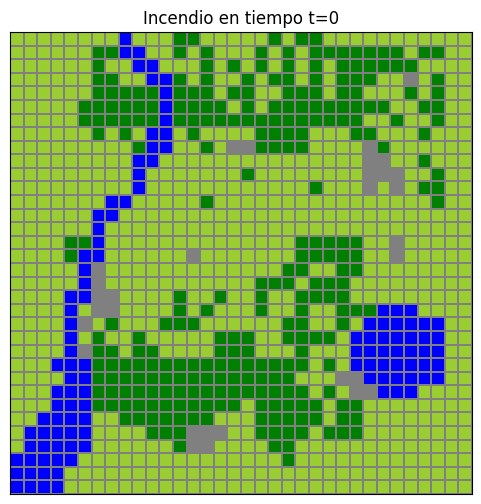

Número de incendios: 6
Ubucaciones de los incendios : [[16, 21, 21], [32, 7, 12], [39, 5, 30], [32, 4, 7], [22, 13, 16], [17, 7, 33]]


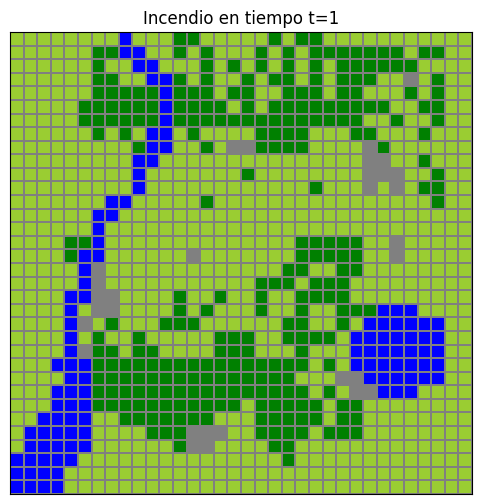

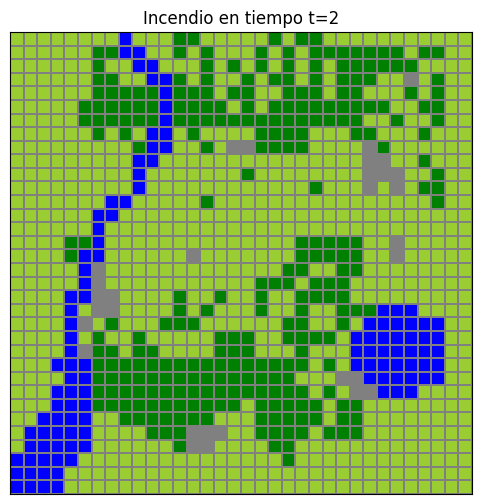

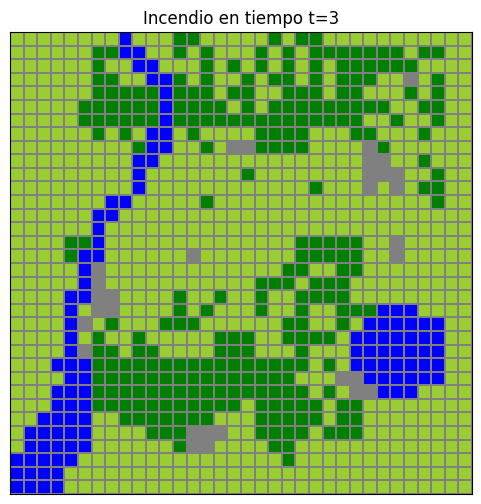

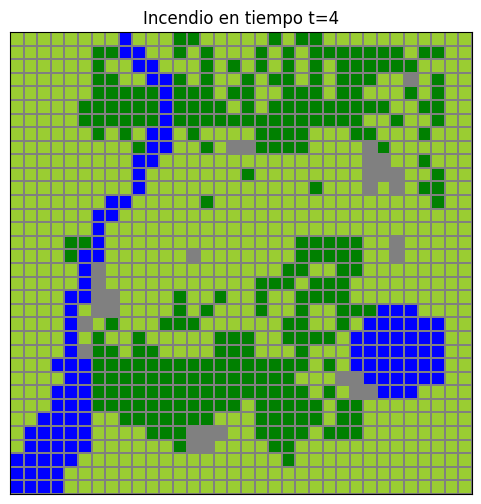

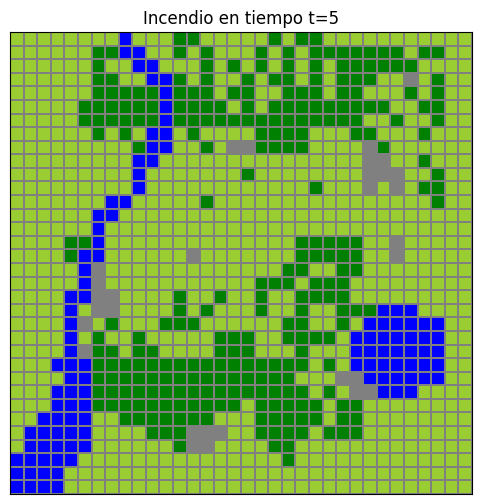

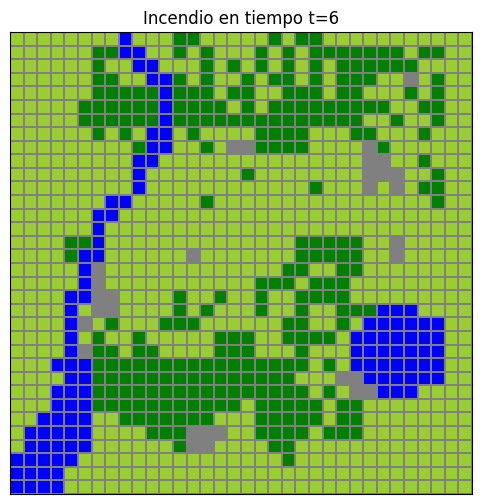

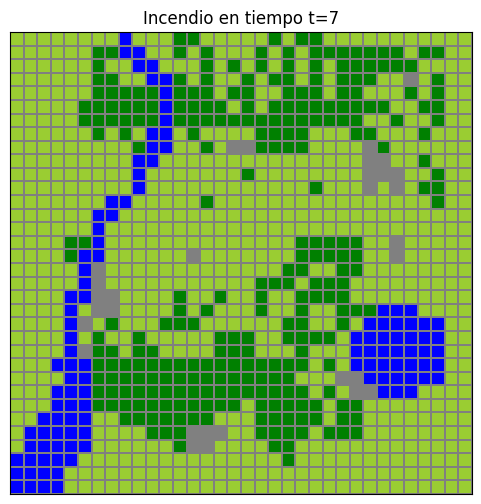

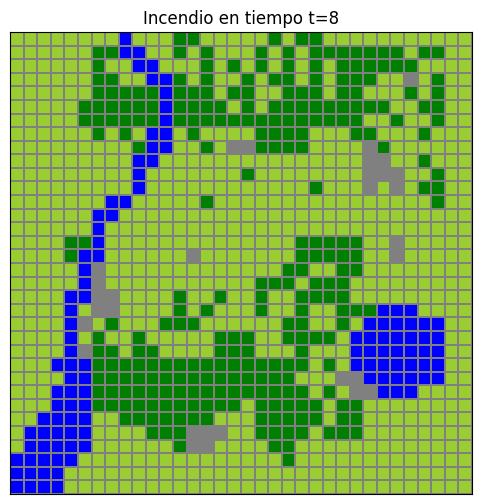

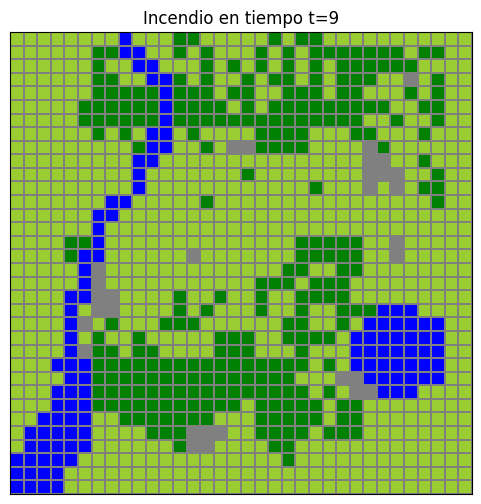

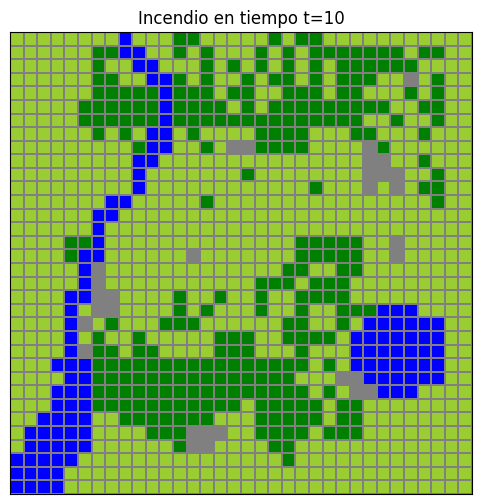

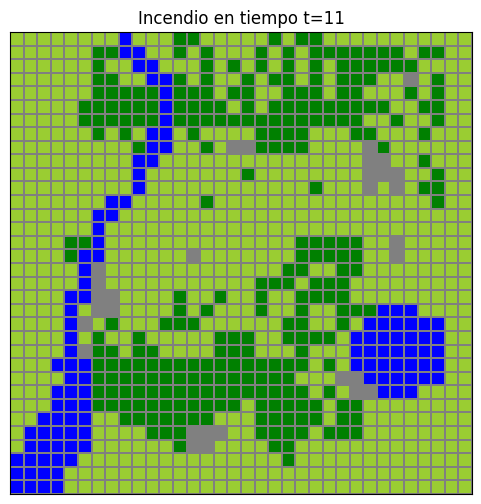

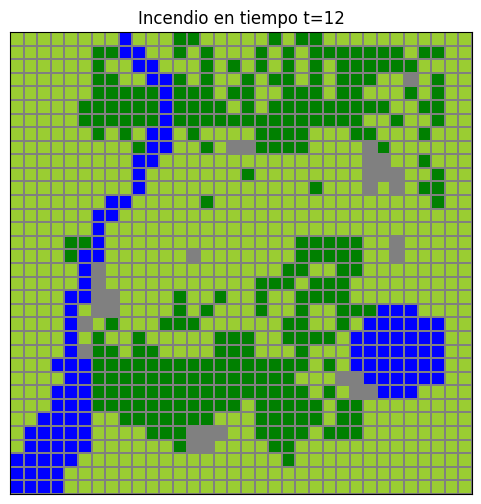

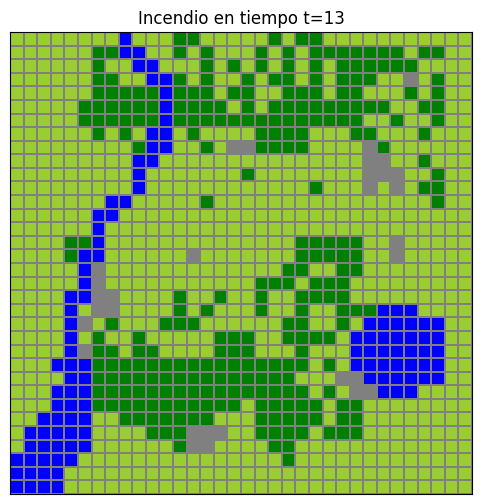

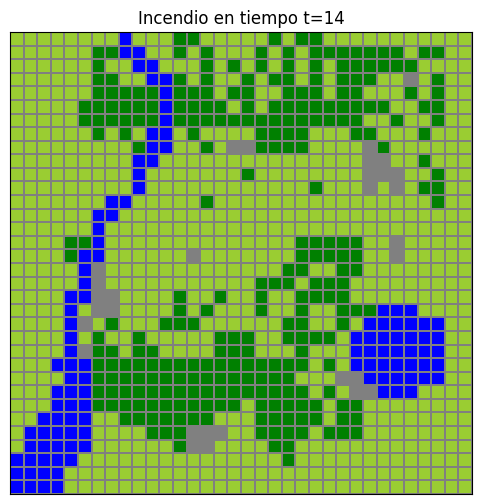

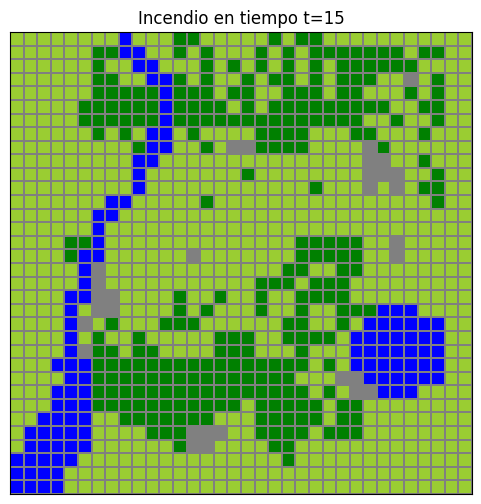

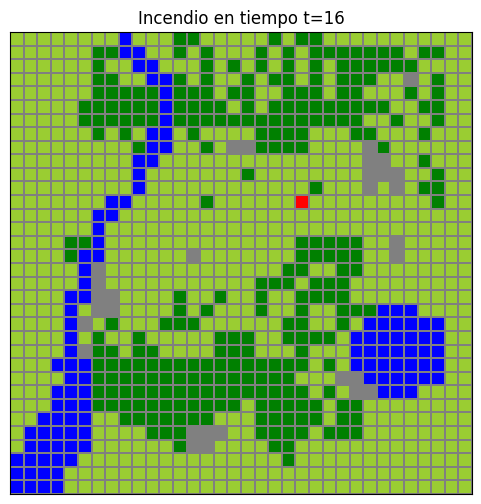

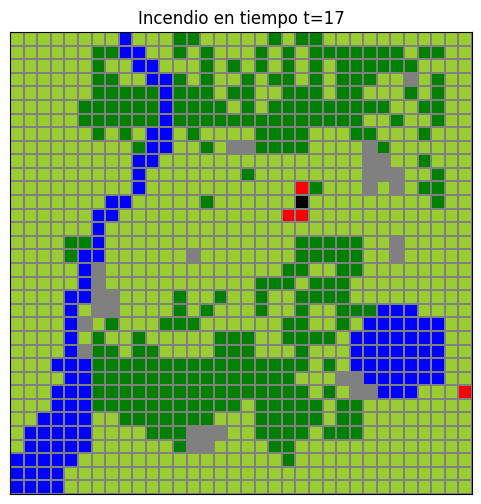

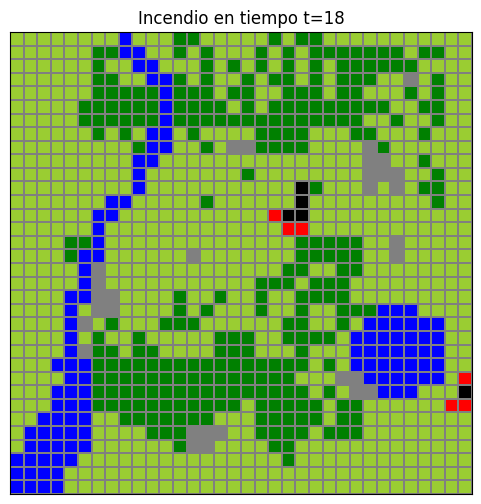

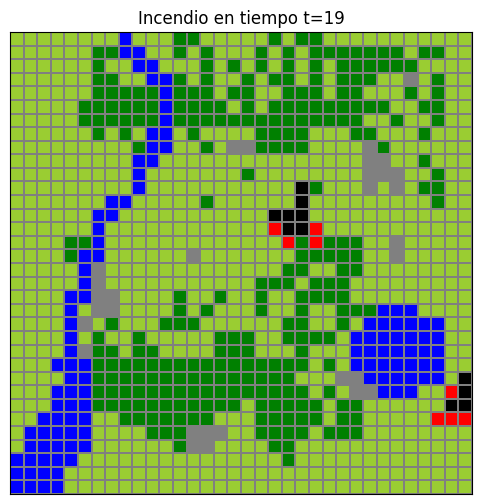

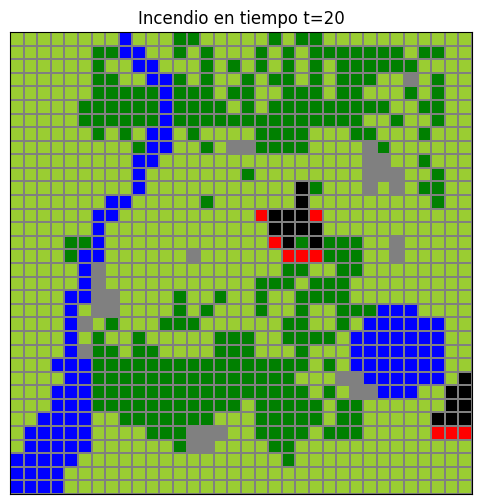

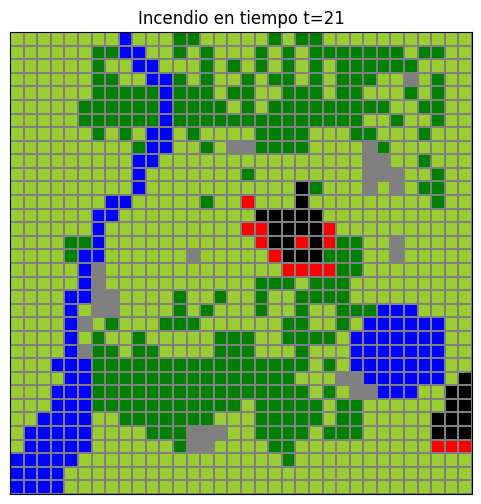

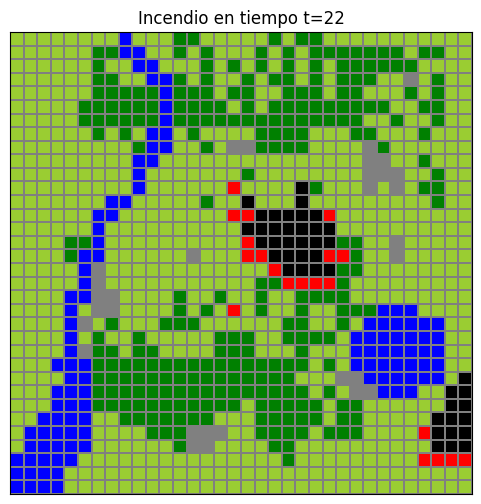

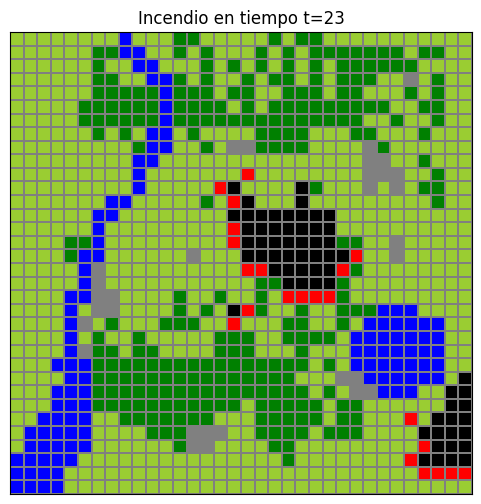

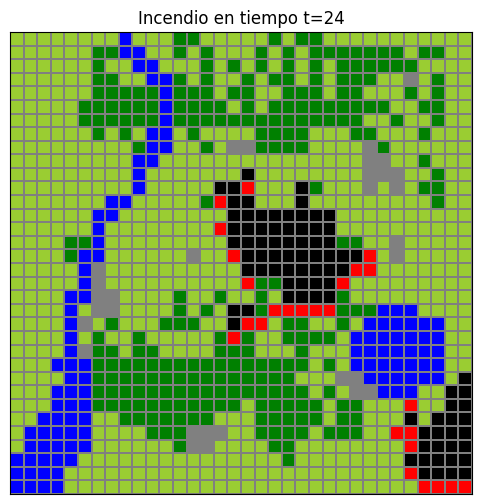

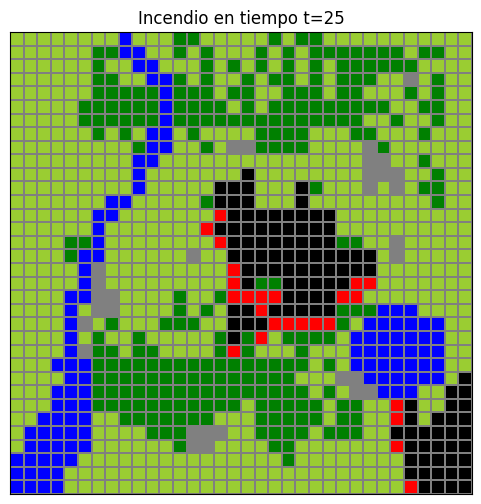

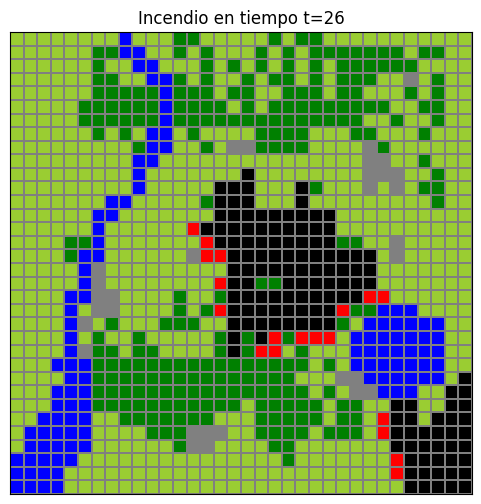

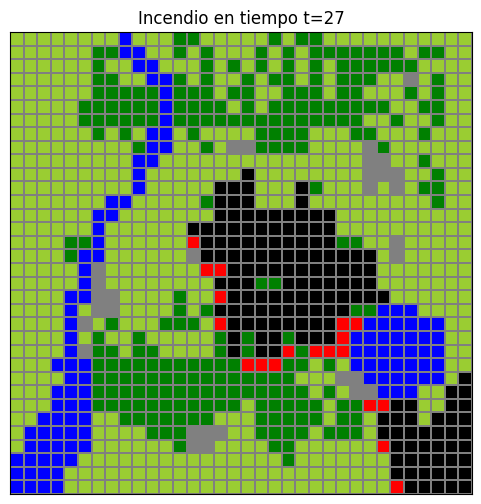

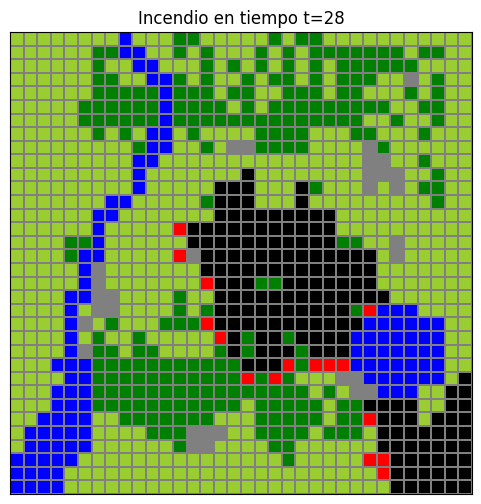

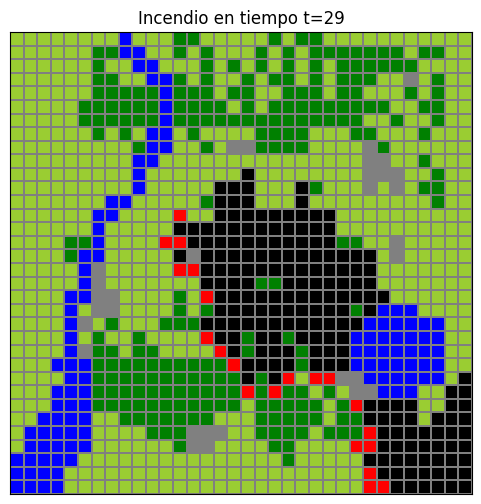

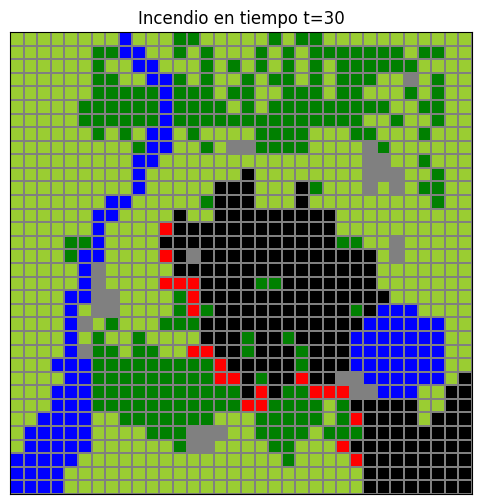

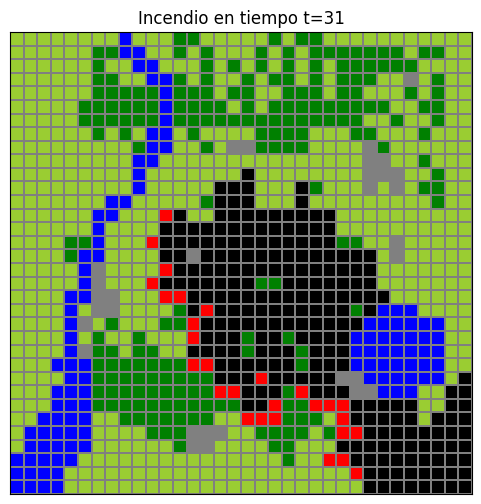

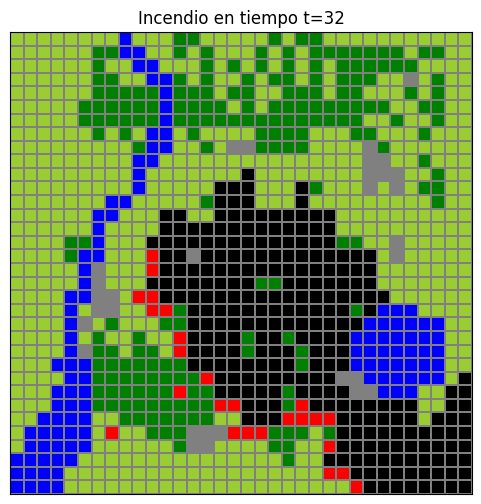

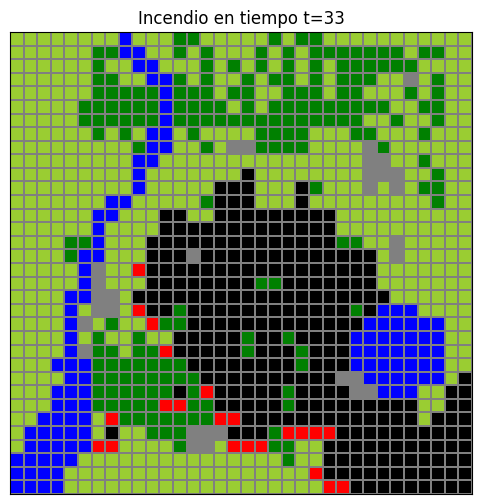

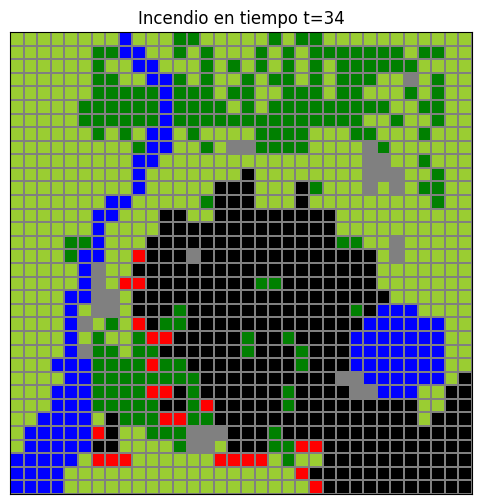

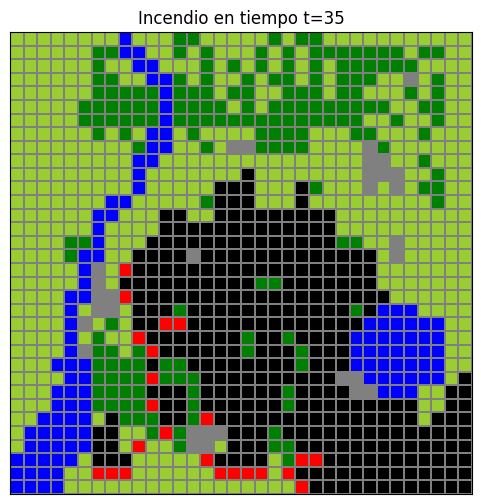

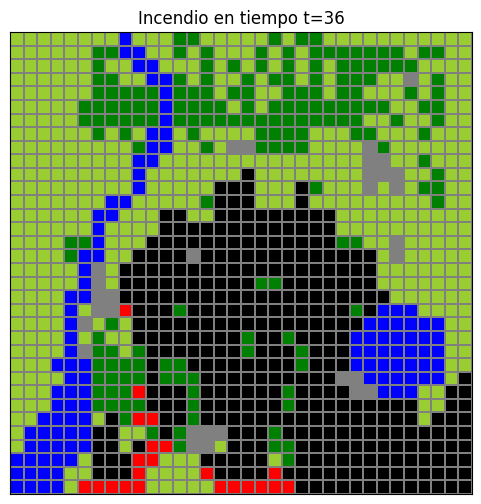

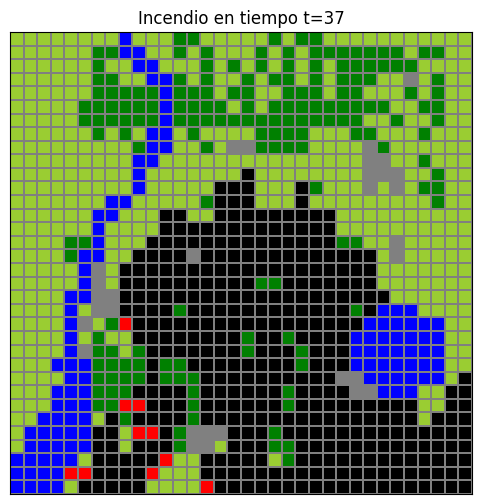

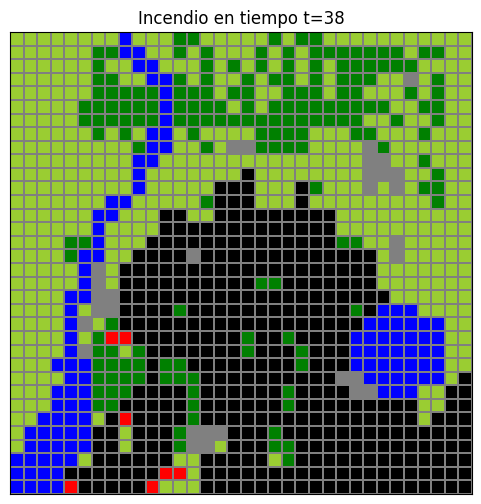

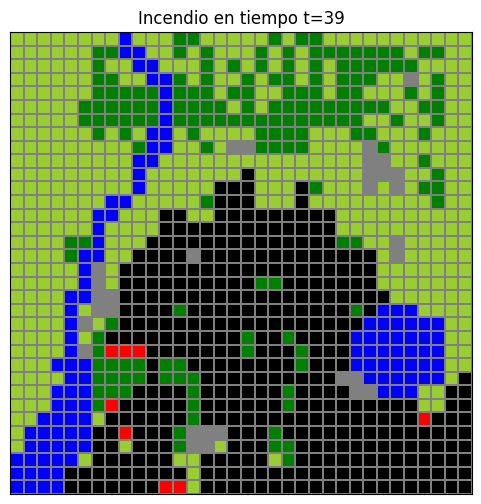

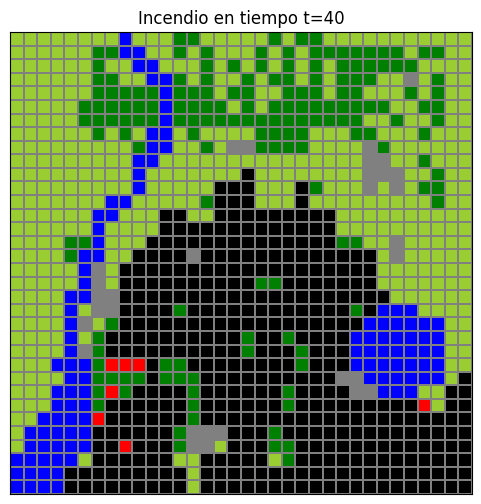

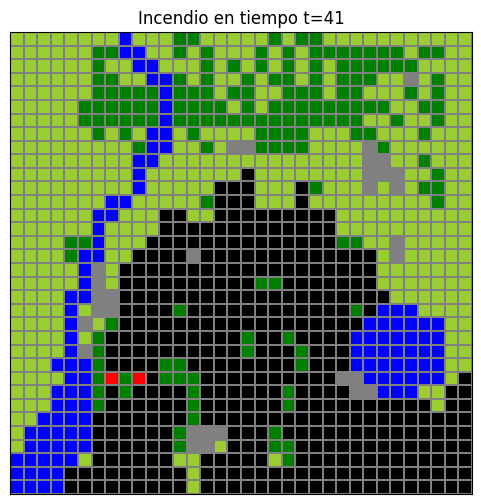

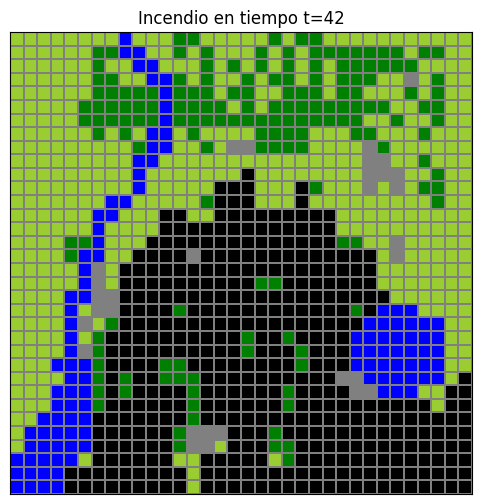

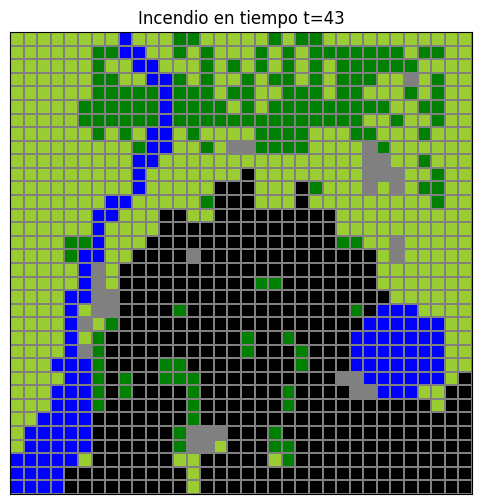

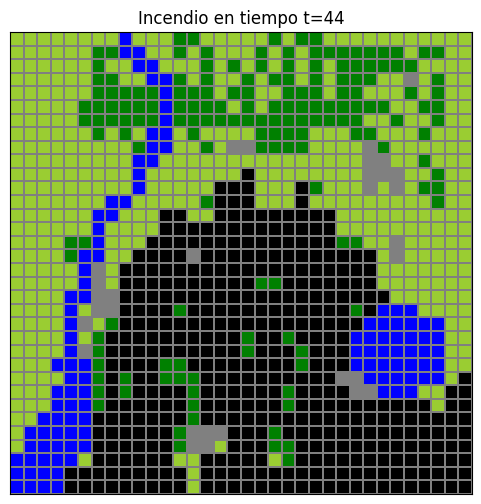

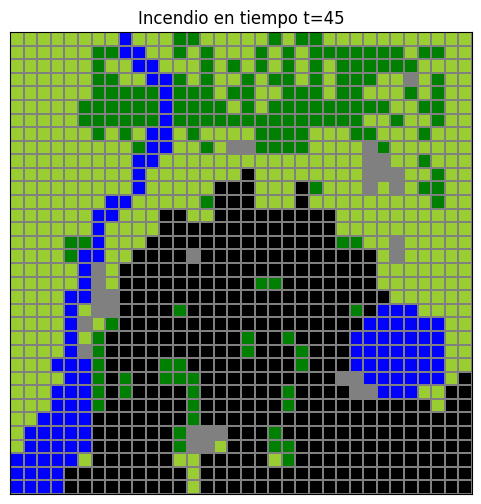

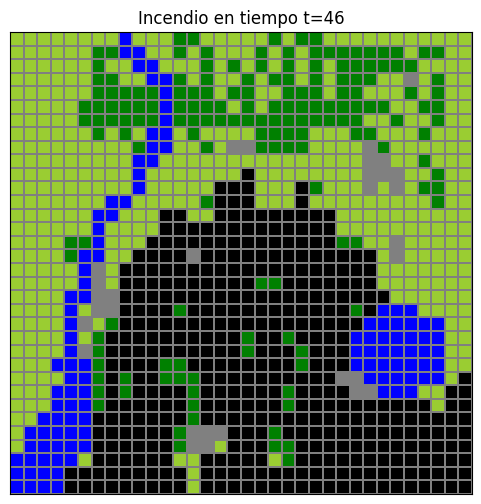

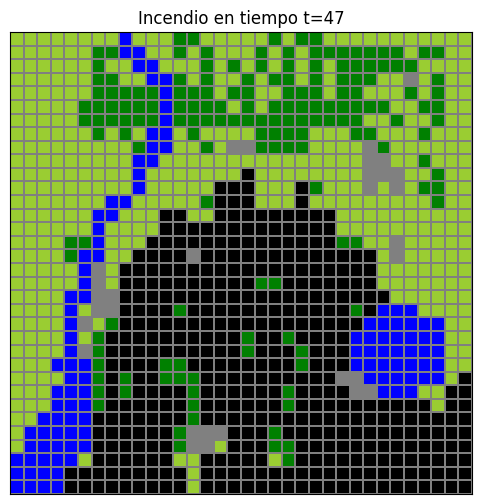

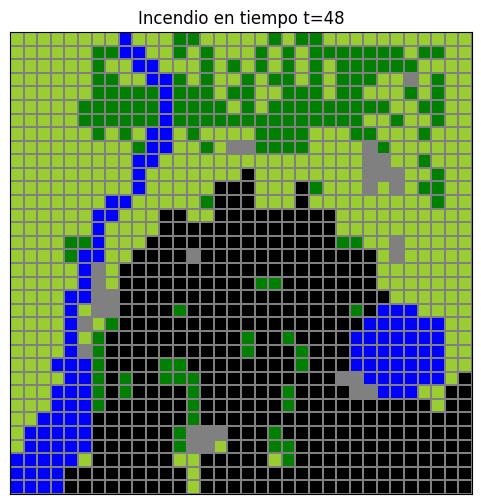

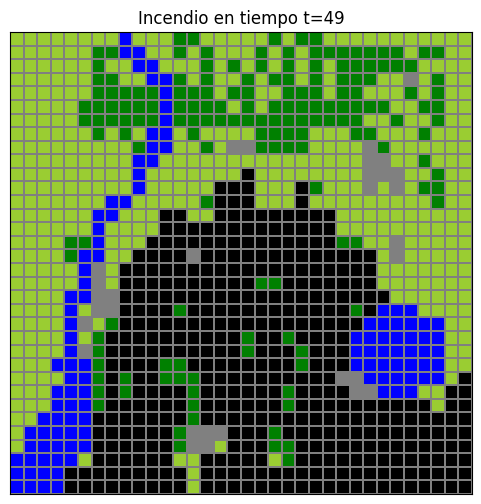

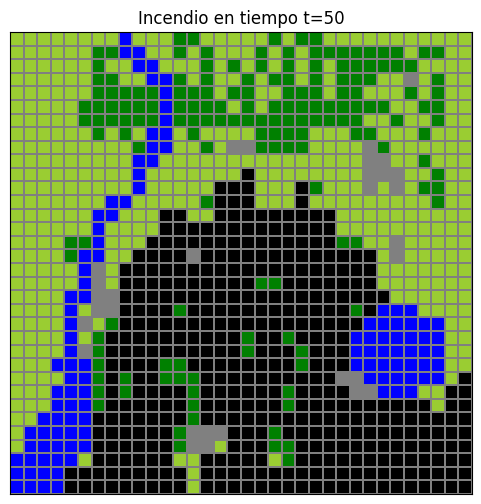

In [15]:
#Ejemplo de simulación:
# Parámetros:
#   direccion : S
#   T : 50

simulacion("S", 50)